In [1]:
#conect with drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["GITHUB_TOKEN"] = "xx"
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"] = "xx"

In [3]:
#!sed -i 's/\r$//' /content/drive/MyDrive/apai/fetch_src.sh  # Windows users
!bash /content/drive/MyDrive/apai/fetch_src.sh

 fetch_src.sh — Download /src from GitHub

Checking environment...
GITHUB_TOKEN set
Fetching file list from GitHub API...
Found 15 file(s) under /src/
src/cl_strategies/ewc.py -> /content/src/cl_strategies/ewc.py
src/cl_strategies/naive.py -> /content/src/cl_strategies/naive.py
src/cl_strategies/reharsal.py -> /content/src/cl_strategies/reharsal.py
src/config/config.py -> /content/src/config/config.py
src/data/dataset.py -> /content/src/data/dataset.py
src/data/preprocessing.py -> /content/src/data/preprocessing.py
src/data/study_dataset.py -> /content/src/data/study_dataset.py
src/fine_tune/trainer.py -> /content/src/fine_tune/trainer.py
src/fine_tune/visualizer.py -> /content/src/fine_tune/visualizer.py
src/imports.py -> /content/src/imports.py
src/meta_learning/mamal.py -> /content/src/meta_learning/mamal.py
src/meta_learning/reptil.py -> /content/src/meta_learning/reptil.py
src/models/baselines.py -> /content/src/models/baselines.py
src/models/pretrained.py -> /content/src/models/p

In [4]:
#!sed -i 's/\r$//' /content/drive/MyDrive/apai/setup_colab.sh    # Windows users
!bash /content/drive/MyDrive/apai/setup_colab.sh


UCF101 Project — Colab Setup Script

Checking environment...
KAGGLE_USERNAME set
KAGGLE_KEY set
config.py found

Installing kagglehub...
Done.

Using Colab cache for faster access to the 'ucf101-action-recognition' dataset.
Dataset path: /kaggle/input/ucf101-action-recognition

Detecting path and updating config.py...
Found in Kaggle input: /kaggle/input/ucf101-action-recognition/
DATASET_ROOT = '/kaggle/input/ucf101-action-recognition/'
OUTPUT_ROOT  = '/kaggle/working/ucf101-processed/'

Setup complete!
config.py updated on Drive.
Restarting kernel in 5 seconds...
Dataset cache stays on disk.
Run Cell 3 after restart to verify.
Restarting in 5...
Restarting in 4...
Restarting in 3...
Restarting in 2...
Restarting in 1...


In [5]:
# imports
%run /content/src/imports.py

Using device: cuda


## **Preprocess**

In [6]:
# BASE
cfg.OUTPUT_ROOT = "./UCF101/processed_data_base"
preprocess_dataset(splits=["train", "test"], target_classes=cfg.SELECTED_CLASSES)


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_base
Classes: 10 | Limit: Full

Processing split: train



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_base


In [7]:

# TASK 1
cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task1"
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_1)

# TASK 2
cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task2"
preprocess_dataset(splits=["train", "val", "test"], target_classes=cfg.TASK_2)

# TASK 3
#cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task3"
#preprocess_dataset(splits=["train", "val", "test"])

# TASK 4
#cfg.OUTPUT_ROOT      = "./UCF101/processed_data_task4"
#preprocess_dataset(splits=["train", "val", "test"])


--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_task1
Classes: 3 | Limit: Full

Processing split: train


  ApplyEyeMakeup [train]:   0%|          | 0/108 [00:00<?, ?it/s]


Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_task1

--- Preprocessing UCF101 ---
From: /kaggle/input/ucf101-action-recognition/
To  : ./UCF101/processed_data_task2
Classes: 3 | Limit: Full

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: ./UCF101/processed_data_task2


## **Dataloaders**

In [9]:
# indexes
ALL_CLASSES_LIST      = cfg.SELECTED_CLASSES + cfg.TASK_1
class_to_idx          = {cls: i for i, cls in enumerate(ALL_CLASSES_LIST)}
original_class_to_idx = {cls: i for i, cls in enumerate(cfg.SELECTED_CLASSES)}
total_classes         = len(ALL_CLASSES_LIST)

# datasets
base_test    = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "test"),  class_to_idx=class_to_idx)
task1_train  = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx)
task1_val    = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "val"),   class_to_idx=class_to_idx)
task1_test   = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx)

# loaders
base_test_loader     = DataLoader(base_test,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_train_loader   = DataLoader(task1_train, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task1_val_loader     = DataLoader(task1_val,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_loader    = DataLoader(task1_test,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
combined_test_loader = DataLoader(ConcatDataset([base_test, task1_test]),
                                  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
# fisher loader for base task
base_fisher_loader   = DataLoader(
    UCF101Clips(os.path.join(cfg.BASE_ROOT, "train"), class_to_idx=original_class_to_idx),
    batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2
)

In [10]:
# load base model 10 classes not yet expanded
model_ewc = ResNet50LSTM(num_classes=len(cfg.SELECTED_CLASSES)).to(device)
model_ewc.load_state_dict(torch.load(cfg.RESNET50_PATH, map_location=device))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


<All keys matched successfully>

## **Task 1**

In [11]:
fisher_dict, optpar_dict = {}, {}
fisher_dict, optpar_dict = compute_fisher(
    model_ewc, base_fisher_loader, device,
    task_id=0, fisher_dict=fisher_dict, optpar_dict=optpar_dict
)

[Fisher] task_id=0 | samples=994 | mean=0.027579


In [12]:
model_ewc = expand_classifier(model_ewc, new_num_classes=total_classes).to(device)
print(f"FC expanded {len(cfg.SELECTED_CLASSES)} -> {total_classes} classes")
fisher_dict, optpar_dict = pad_fisher_after_expand(fisher_dict, optpar_dict, model_ewc)

FC expanded 10 -> 13 classes
  [pad] fc.weight: torch.Size([10, 256]) -> torch.Size([13, 256])
  [pad] fc.bias: torch.Size([10]) -> torch.Size([13])


In [13]:
check_ewc_penalty(model_ewc, fisher_dict, optpar_dict, cfg.EWC_LAMBDA, device)


[EWC pre-check] raw=0.000000 | scaled (λ=5000.0)=0.0000 | OK



(0.0, 0.0)

In [14]:
optimizer_t1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ewc.parameters()),
    lr=cfg.EWC_LR, weight_decay=cfg.EWC_WD
)
train_ewc(
    model_ewc,
    task1_train_loader,
    task1_val_loader,
    optimizer_t1,
    device,                  
    fisher_dict=fisher_dict,
    optpar_dict=optpar_dict,
    ewc_lambda=cfg.EWC_LAMBDA, 
    epochs=cfg.EWC_EPOCHS,
    task_label="Task1"
)

[Task1] Epoch 01/5 | Loss 2.7182 (CE 2.5897 + EWC 0.1284) | Val Acc 0.3000
[Task1] Epoch 02/5 | Loss 1.8543 (CE 1.6126 + EWC 0.2418) | Val Acc 0.7000
[Task1] Epoch 03/5 | Loss 1.3151 (CE 1.0102 + EWC 0.3050) | Val Acc 0.7800
[Task1] Epoch 04/5 | Loss 1.0039 (CE 0.6954 + EWC 0.3085) | Val Acc 0.8600
[Task1] Epoch 05/5 | Loss 0.8158 (CE 0.5207 + EWC 0.2951) | Val Acc 0.9000


In [15]:
ewc_report(model_ewc, fisher_dict, optpar_dict)


  Task 0 | Mean Fisher: 0.025563 | Mean Drift: 0.000018 | Total Penalty: 0.0001
    1. resnet.7.2.conv2.weight                         17.1%
    2. resnet.7.2.conv3.weight                         15.2%
    3. lstm.weight_ih_l0                               15.2%
    4. resnet.7.0.downsample.0.weight                  10.5%
    5. resnet.7.2.conv1.weight                          7.8%


Running Inference on Test Set...


Test Accuracy: 0.9509


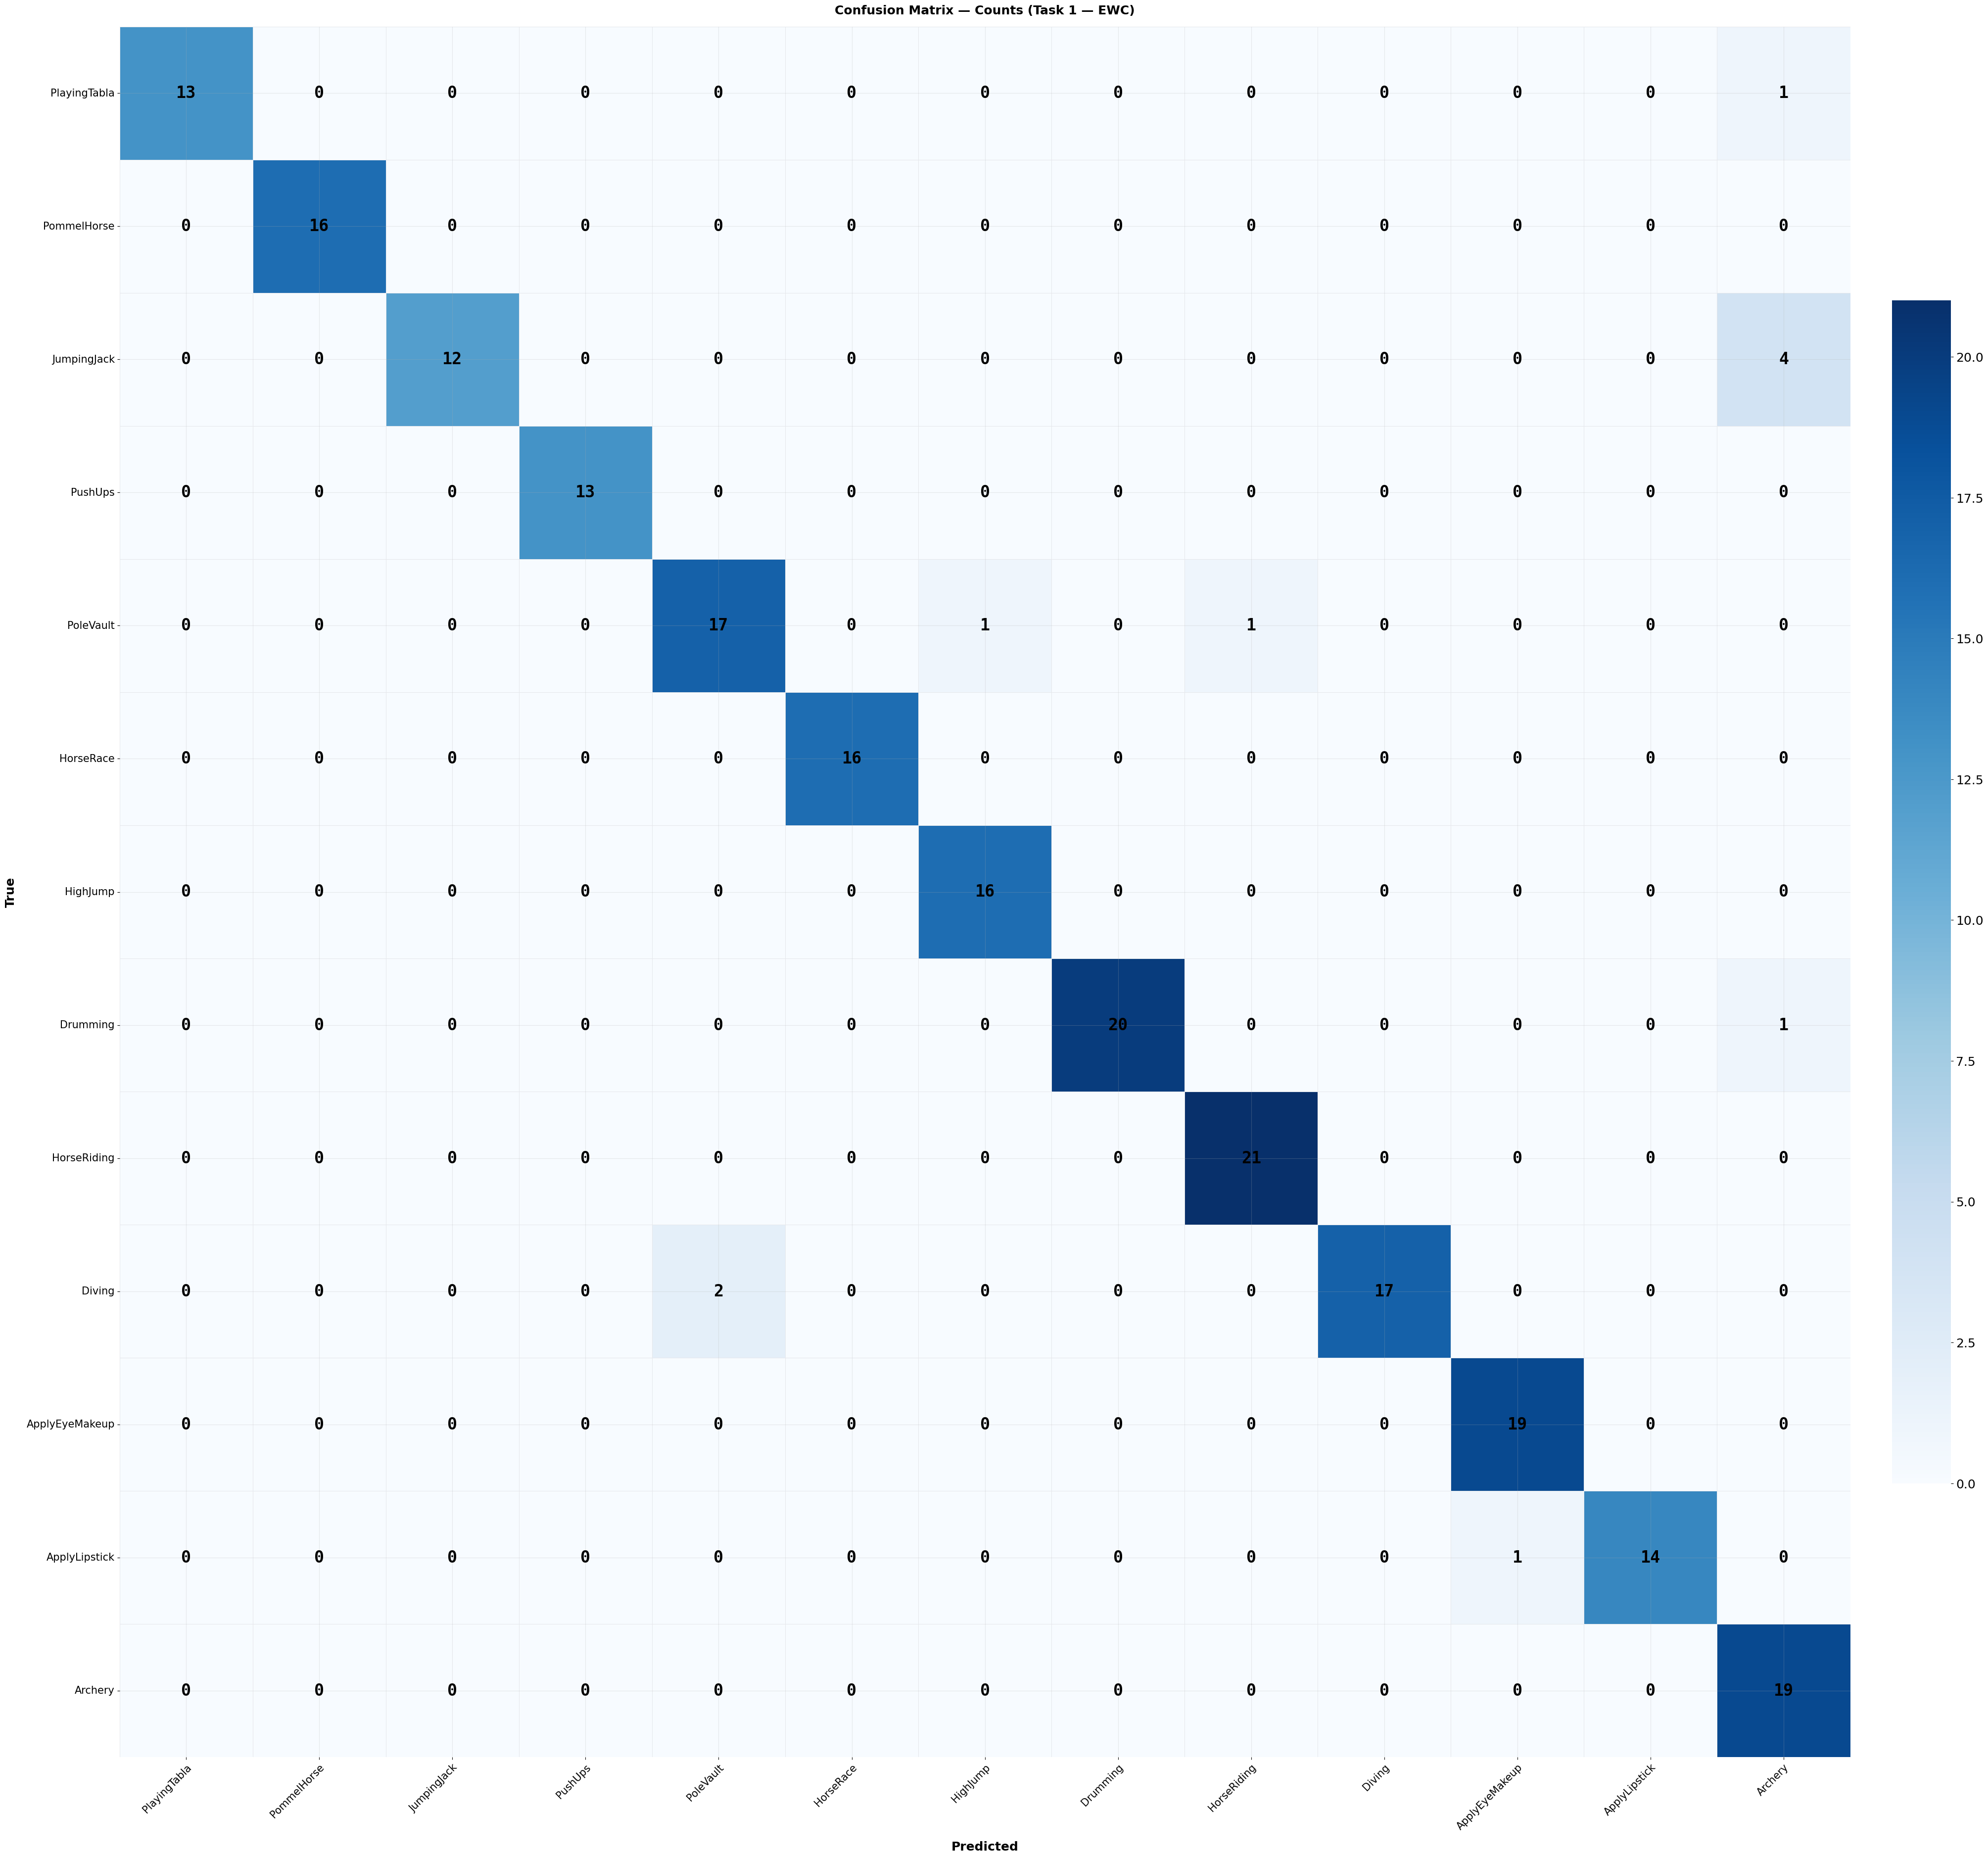

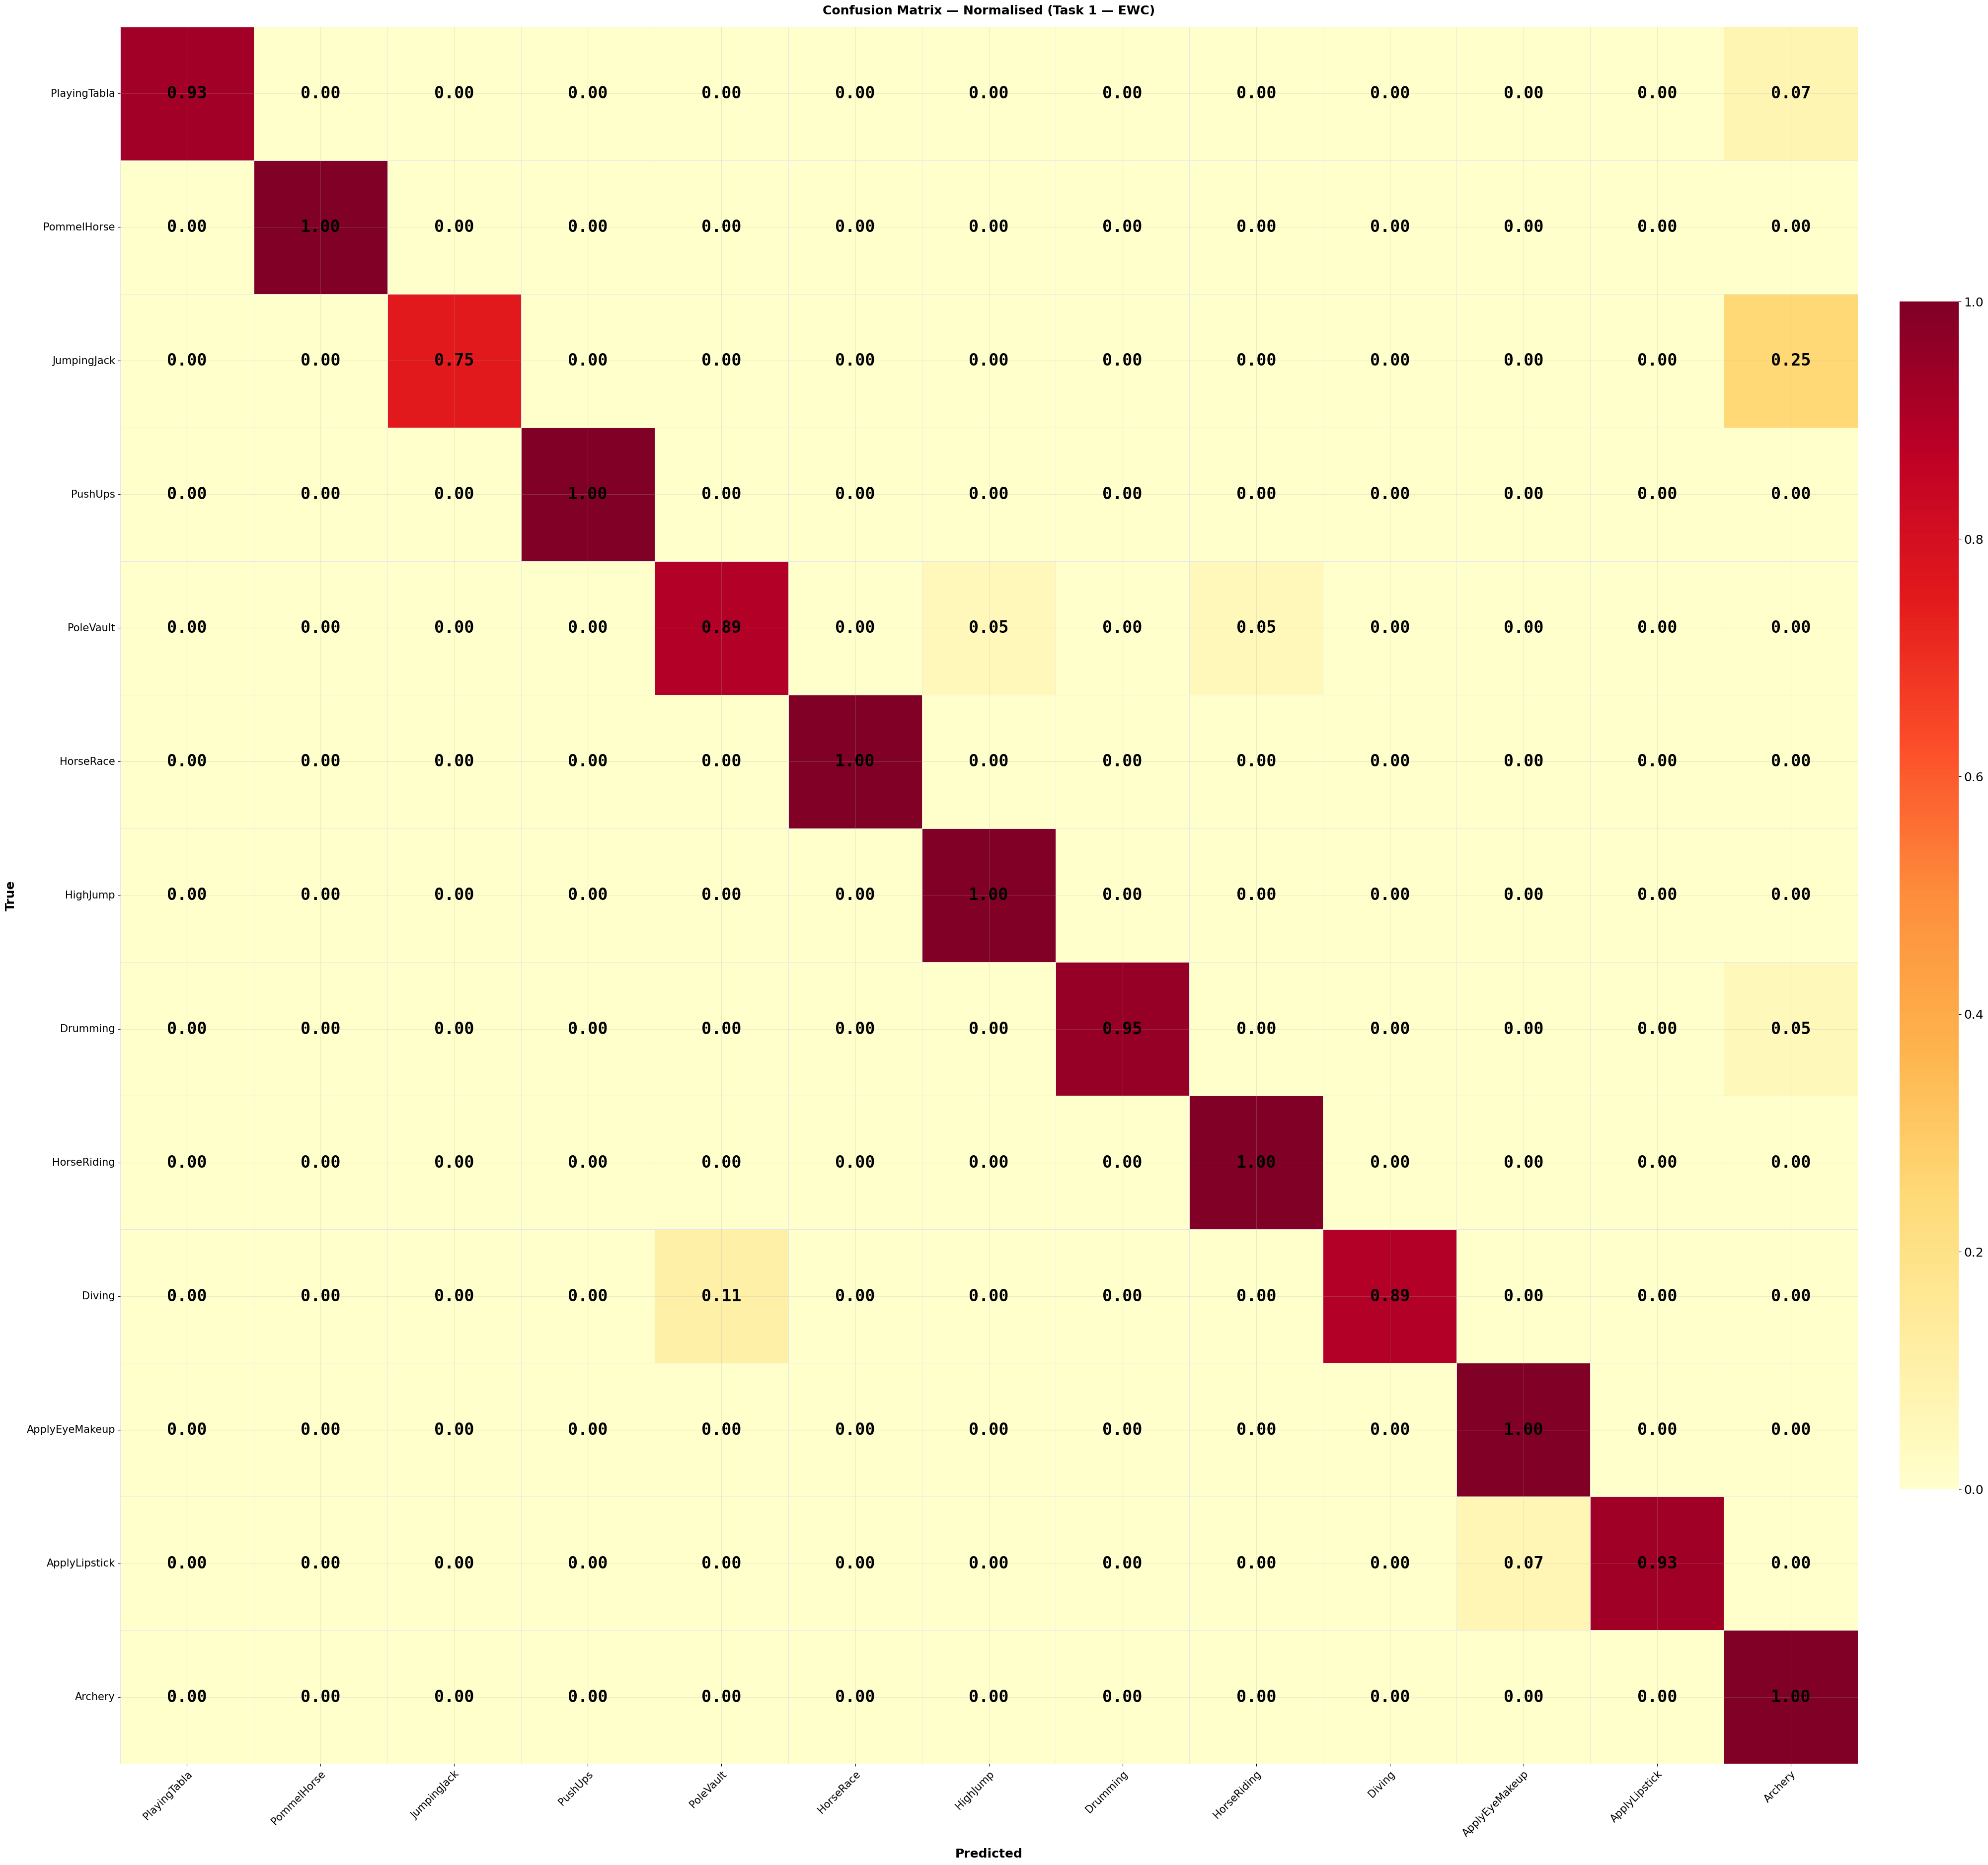

In [16]:
_, all_preds, all_labels = test_model(model_ewc, combined_test_loader, device)

plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_LIST),
    classes_list = ALL_CLASSES_LIST,
    name         = "Task 1 — EWC",
)

## **Task 2**

In [17]:
ALL_CLASSES_T2   = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2
class_to_idx_t2  = {cls: i for i, cls in enumerate(ALL_CLASSES_T2)}
total_classes_t2 = len(ALL_CLASSES_T2)

base_test_t2  = UCF101Clips(os.path.join(cfg.BASE_ROOT,  "test"),  class_to_idx=class_to_idx_t2)
task1_test_t2 = UCF101Clips(os.path.join(cfg.TASK1_ROOT, "test"),  class_to_idx=class_to_idx_t2)

task2_train   = UCF101Clips(os.path.join(cfg.OUTPUT_ROOT, "train"), class_to_idx=class_to_idx_t2)
task2_val     = UCF101Clips(os.path.join(cfg.OUTPUT_ROOT, "val"),   class_to_idx=class_to_idx_t2)
task2_test    = UCF101Clips(os.path.join(cfg.OUTPUT_ROOT, "test"),  class_to_idx=class_to_idx_t2)

base_test_t2_loader   = DataLoader(base_test_t2,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task1_test_t2_loader  = DataLoader(task1_test_t2, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_train_loader    = DataLoader(task2_train,   batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=2)
task2_val_loader      = DataLoader(task2_val,     batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
task2_test_loader     = DataLoader(task2_test,    batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2)
combined_t2_loader    = DataLoader(
    ConcatDataset([base_test_t2, task1_test_t2, task2_test]),
    batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2
)
task1_fisher_loader   = DataLoader(
    UCF101Clips(os.path.join(cfg.TASK1_ROOT, "train"), class_to_idx=class_to_idx_t2),
    batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2
)

In [18]:
fisher_dict, optpar_dict = compute_fisher(model_ewc, task1_fisher_loader, device, task_id=1, fisher_dict=fisher_dict, optpar_dict=optpar_dict)

[Fisher] task_id=1 | samples=301 | mean=0.024490


In [19]:
model_ewc = expand_classifier(model_ewc, new_num_classes=total_classes_t2).to(device)
print(f"FC expanded {len(cfg.SELECTED_CLASSES)} -> {total_classes_t2} classes")
fisher_dict, optpar_dict = pad_fisher_after_expand(fisher_dict, optpar_dict, model_ewc)

FC expanded 10 -> 16 classes
  [pad] fc.weight: torch.Size([13, 256]) -> torch.Size([16, 256])
  [pad] fc.bias: torch.Size([13]) -> torch.Size([16])
  [pad] fc.weight: torch.Size([13, 256]) -> torch.Size([16, 256])
  [pad] fc.bias: torch.Size([13]) -> torch.Size([16])


In [20]:
check_ewc_penalty(model_ewc, fisher_dict, optpar_dict, cfg.EWC_LAMBDA, device)


[EWC pre-check] raw=0.000057 | scaled (λ=5000.0)=0.2857 | OK



(5.714036160497926e-05, 0.2857018080248963)

In [21]:
optimizer_t2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ewc.parameters()),
    lr=cfg.EWC_LR, weight_decay=cfg.EWC_WD
)
train_ewc(
    model_ewc,
    task2_train_loader,
    task2_val_loader,
    optimizer_t2,
    device,                  
    fisher_dict=fisher_dict,
    optpar_dict=optpar_dict,
    ewc_lambda=cfg.EWC_LAMBDA, 
    epochs=cfg.EWC_EPOCHS,
    task_label="Task2"
)

[Task2] Epoch 01/5 | Loss 3.3340 (CE 2.8971 + EWC 0.4369) | Val Acc 0.1321
[Task2] Epoch 02/5 | Loss 2.4606 (CE 1.8795 + EWC 0.5810) | Val Acc 0.5472
[Task2] Epoch 03/5 | Loss 2.0359 (CE 1.4049 + EWC 0.6310) | Val Acc 0.7736
[Task2] Epoch 04/5 | Loss 1.7745 (CE 1.1268 + EWC 0.6477) | Val Acc 0.8679
[Task2] Epoch 05/5 | Loss 1.6095 (CE 0.9452 + EWC 0.6643) | Val Acc 0.9434


In [22]:
# EWC report
ewc_report(model_ewc, fisher_dict, optpar_dict)


  Task 0 | Mean Fisher: 0.024303 | Mean Drift: 0.000025 | Total Penalty: 0.0001
    1. lstm.weight_ih_l0                               17.0%
    2. resnet.7.2.conv3.weight                         16.9%
    3. resnet.7.2.conv2.weight                         15.7%
    4. resnet.7.0.downsample.0.weight                  10.6%
    5. resnet.7.2.conv1.weight                          8.4%
  Task 1 | Mean Fisher: 0.023182 | Mean Drift: 0.000010 | Total Penalty: 0.0001
    1. lstm.weight_ih_l0                               31.2%
    2. resnet.7.2.conv3.weight                         24.7%
    3. resnet.7.2.conv2.weight                          8.3%
    4. resnet.7.0.downsample.0.weight                   8.3%
    5. resnet.7.2.conv1.weight                          7.7%


Running Inference on Test Set...


Test Accuracy: 0.8351


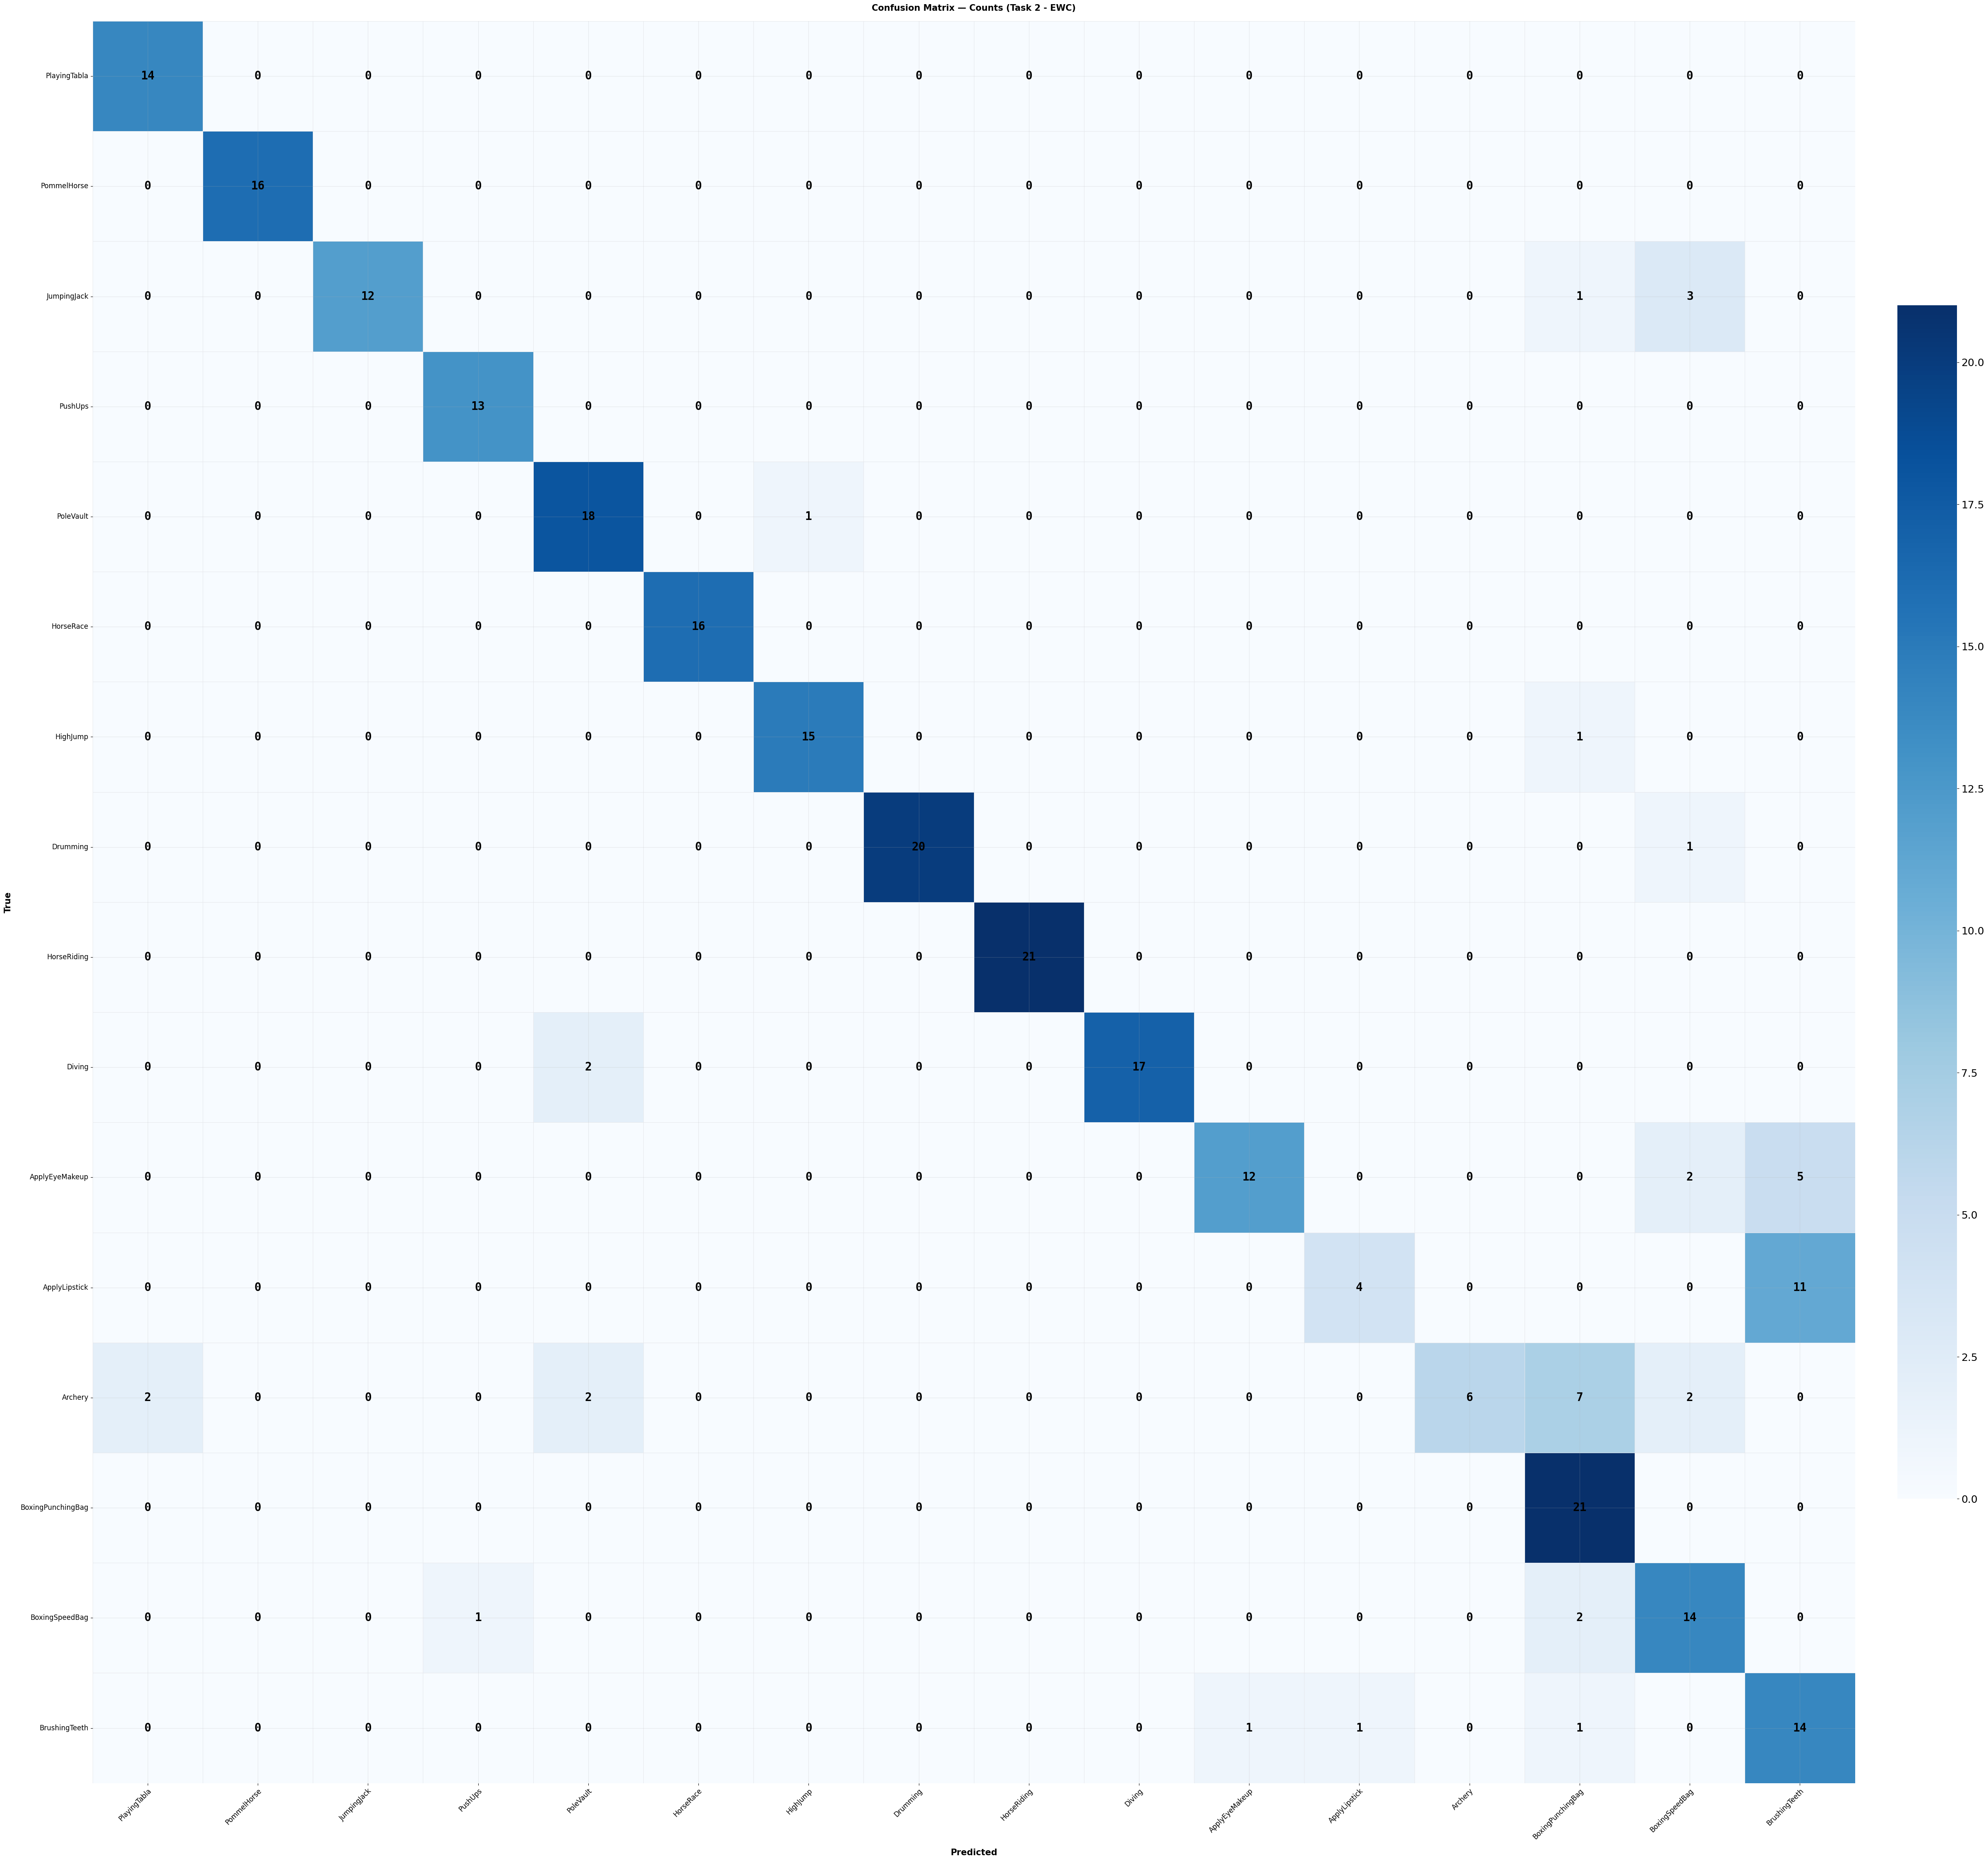

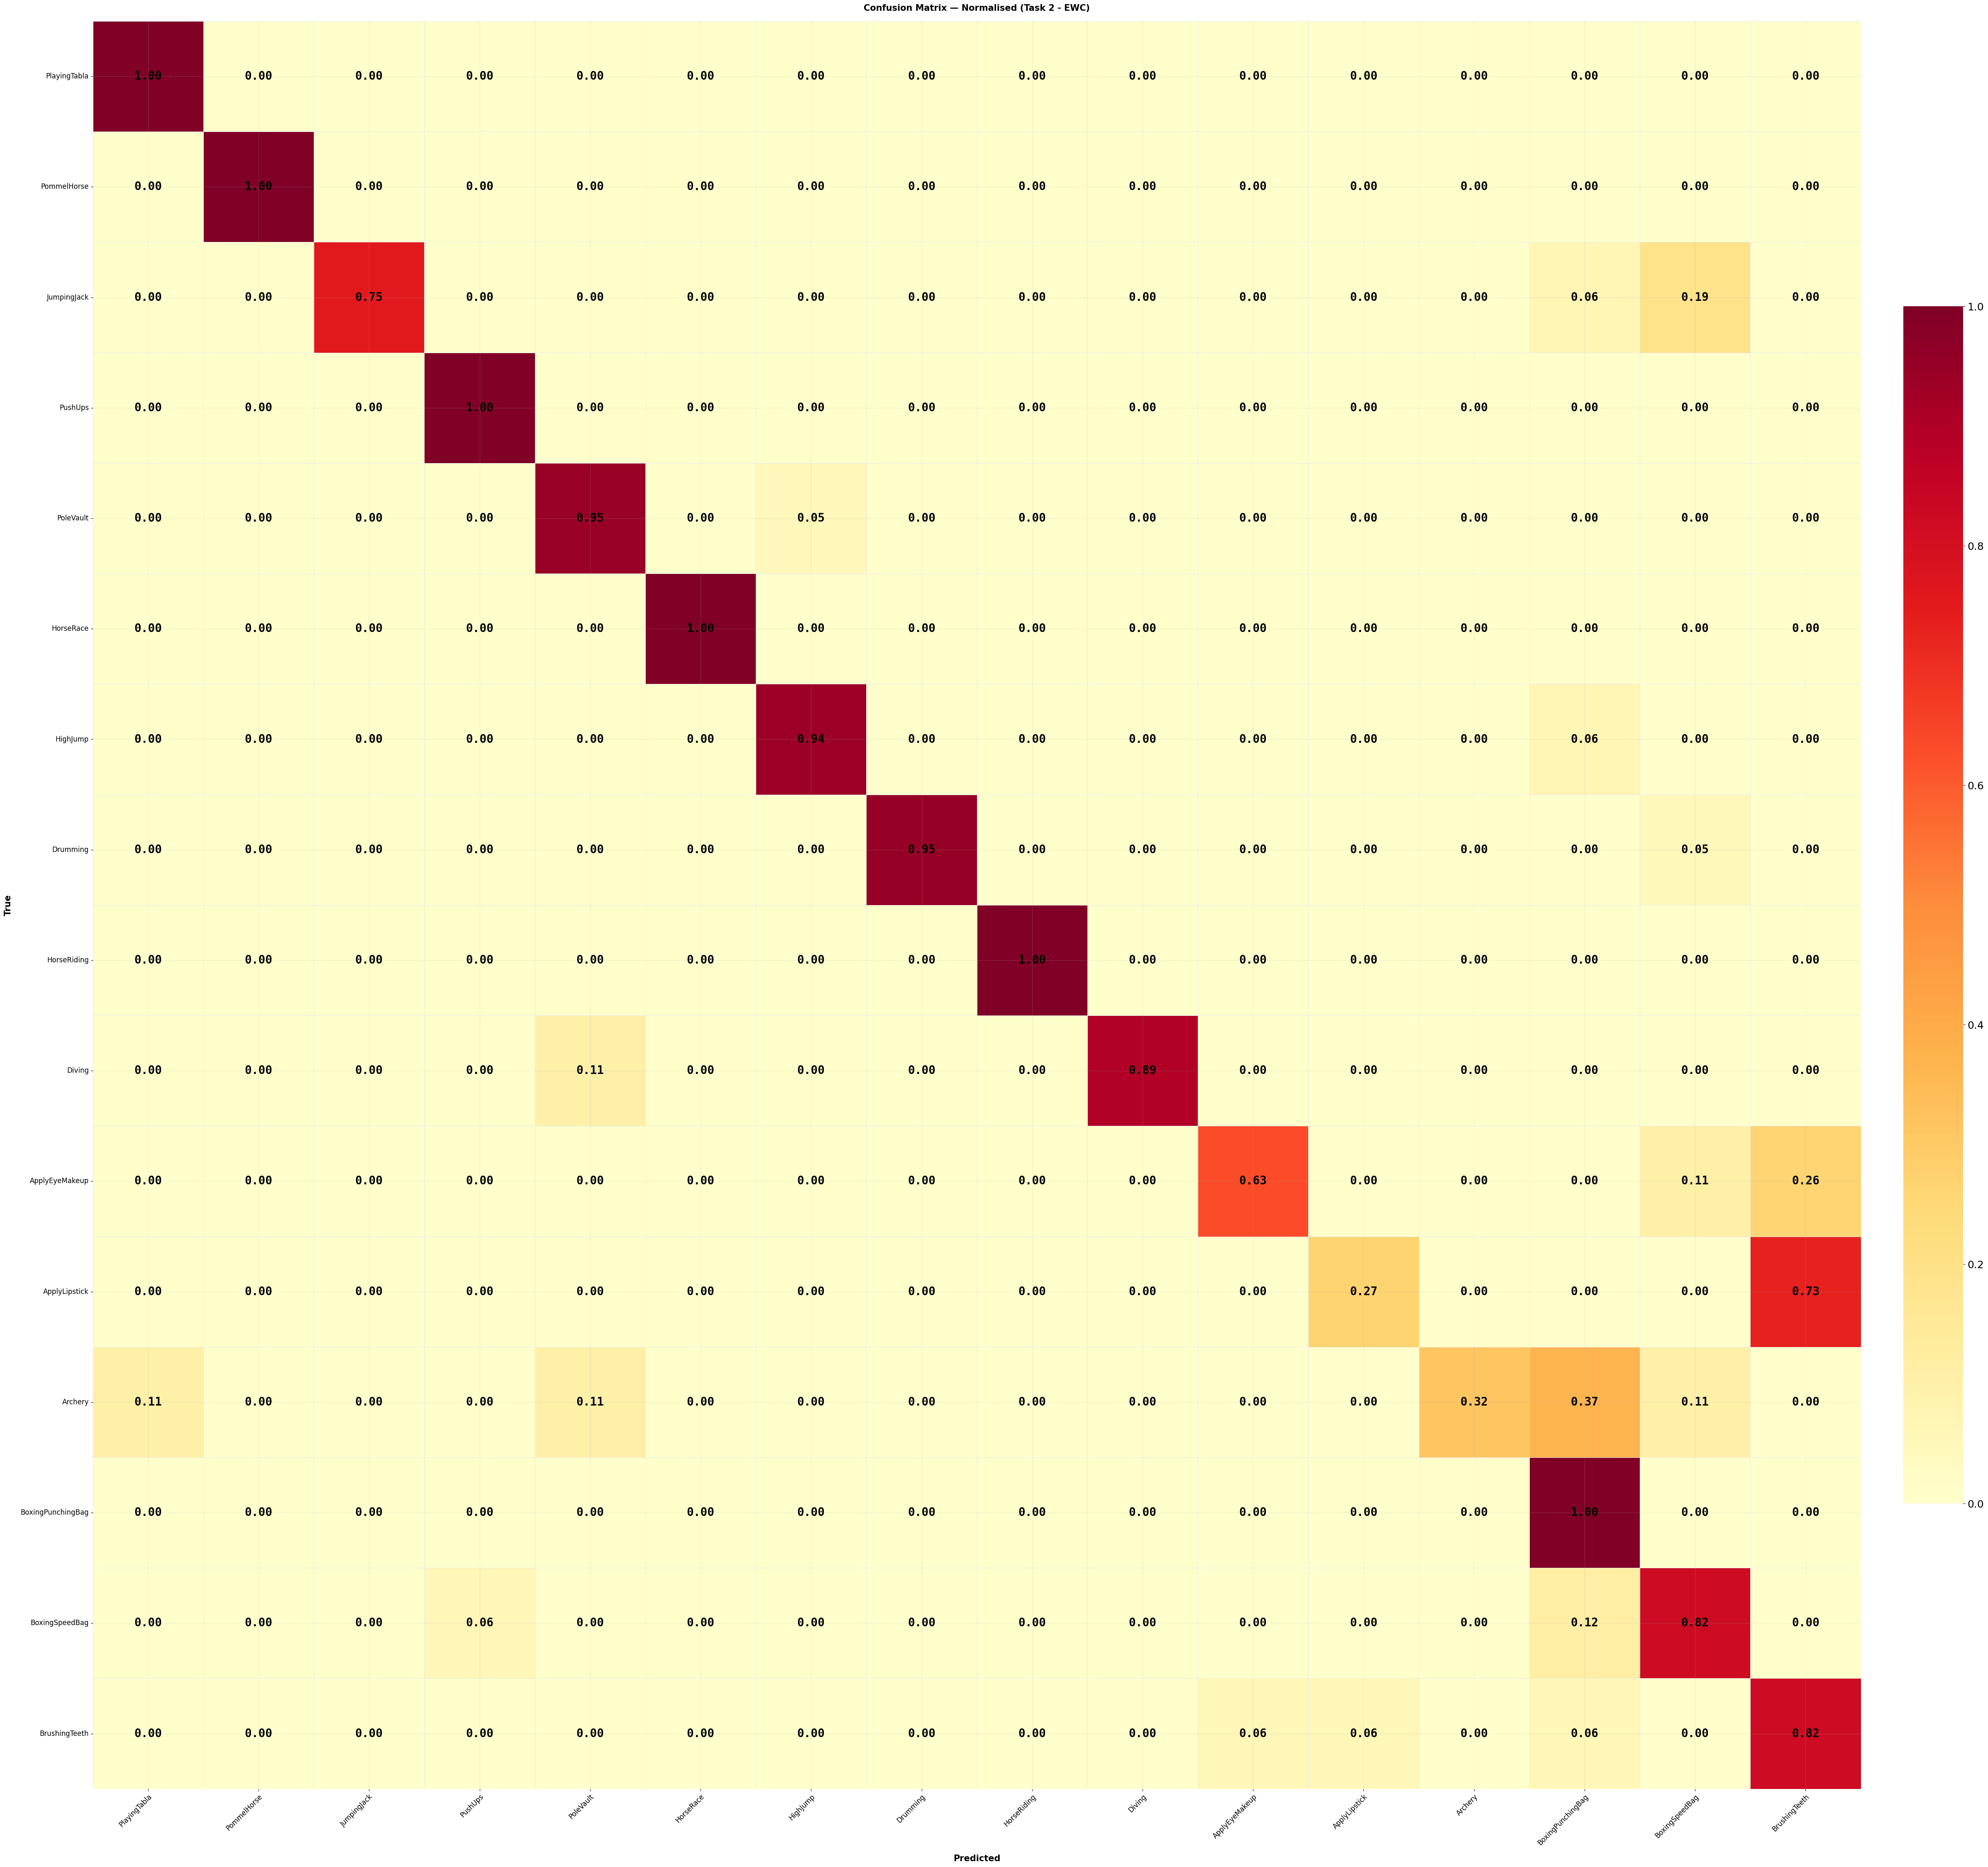

In [23]:
_, all_preds, all_labels = test_model(model_ewc, combined_t2_loader, device)
plot_confusion_matrix(
    all_labels, all_preds,
    num_classes  = len(ALL_CLASSES_T2),
    classes_list = ALL_CLASSES_T2,
    name         = "Task 2 - EWC",
)